# 2_1 Análise de Dados

Este notebook realiza a **análise estatística e linguística** do corpus de notícias brasileiras, incluindo distribuição de tokens, frequência de palavras e visualizações gráficas.

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import pandas as pd
print('Bibliotecas importadas!')

Bibliotecas importadas!


## 1. Carregamento e Pré-processamento

In [ ]:
STOPWORDS_PT = set(['a','ao','aos','as','até','com','como','da','das','de','do','dos','e','ela','elas','ele','eles','em','entre','essa','esse','esta','este','eu','foi','foram','há','isso','já','mais','mas','me','muito','na','nas','não','nos','nós','o','os','ou','para','pela','pelas','pelo','pelos','por','qual','quando','que','quem','se','sem','seu','seus','sua','suas','são','também','um','uma','umas','uns','você','à','às','é','ser','ter'])

def limpar(t):
    t=t.lower(); t=re.sub(r'[^\w\s]','',t); t=re.sub(r'\d+','',t)
    return re.sub(r'\s+',' ',t).strip()

docs_proc=[{'id':i+1,'tokens':limpar(d).split(),'sem_sw':[x for x in limpar(d).split() if x not in STOPWORDS_PT and len(x)>2]} for i,d in enumerate(documentos)]
print(f'{len(docs_proc)} documentos processados!')

32 documentos processados!


## 2. Estatísticas Gerais

In [ ]:
tokens_list=[len(d['tokens']) for d in docs_proc]
sw_list=[len(d['sem_sw']) for d in docs_proc]
print(f"Estatísticas do Corpus:\n{'='*40}\nTotal de documentos     : {len(docs_proc)}\nTotal de tokens         : {sum(tokens_list)}\nTotal sem stopwords     : {sum(sw_list)}\nMédia tokens/doc        : {sum(tokens_list)/len(tokens_list):.1f}\nMínimo tokens/doc       : {min(tokens_list)}\nMáximo tokens/doc       : {max(tokens_list)}\nVocabulário único       : {len(set(t for d in docs_proc for t in d['tokens']))}")

Estatísticas do Corpus:
Total de documentos     : 32
Total de tokens         : 665
Total sem stopwords     : 394
Média tokens/doc        : 20.8
Mínimo tokens/doc       : 17
Máximo tokens/doc       : 28
Vocabulário único       : 338


## 3. Distribuição de Tokens por Documento

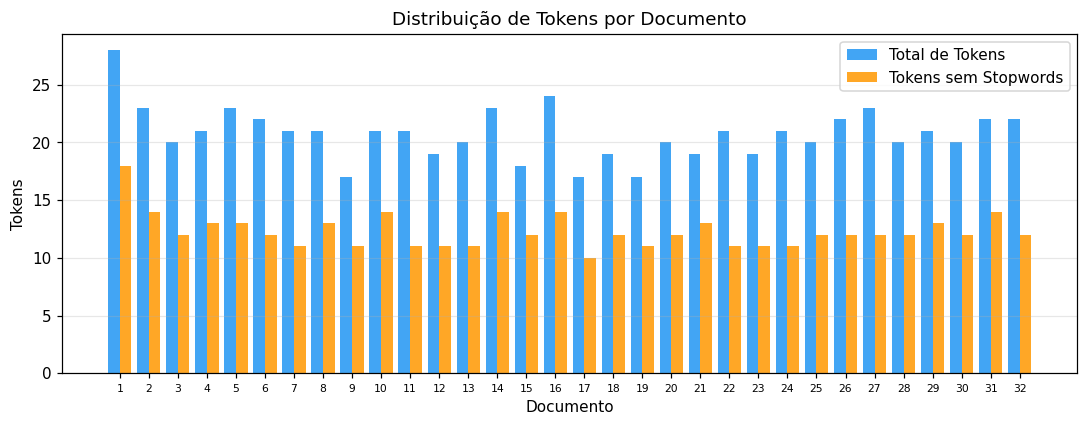

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
x=range(len(docs_proc))
ax.bar([i-0.2 for i in x],tokens_list,0.4,label='Total de Tokens',color='#2196F3',alpha=0.85)
ax.bar([i+0.2 for i in x],sw_list,0.4,label='Tokens sem Stopwords',color='#FF9800',alpha=0.85)
ax.set_xlabel('Documento'); ax.set_ylabel('Tokens')
ax.set_title('Distribuição de Tokens por Documento')
ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Boxplot de Tokens

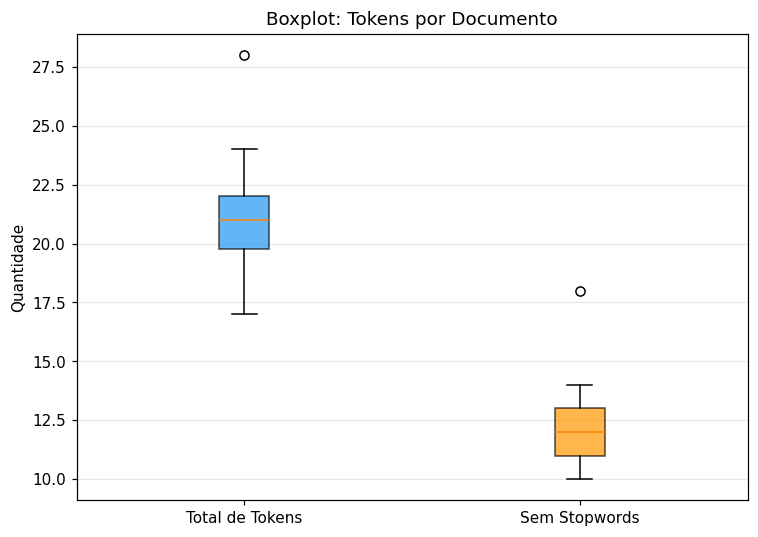

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
bp=ax.boxplot([tokens_list,sw_list],tick_labels=['Total','Sem Stopwords'],patch_artist=True)
bp['boxes'][0].set_facecolor('#2196F3'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#FF9800'); bp['boxes'][1].set_alpha(0.7)
ax.set_title('Boxplot: Tokens por Documento'); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Top 20 Palavras Mais Frequentes

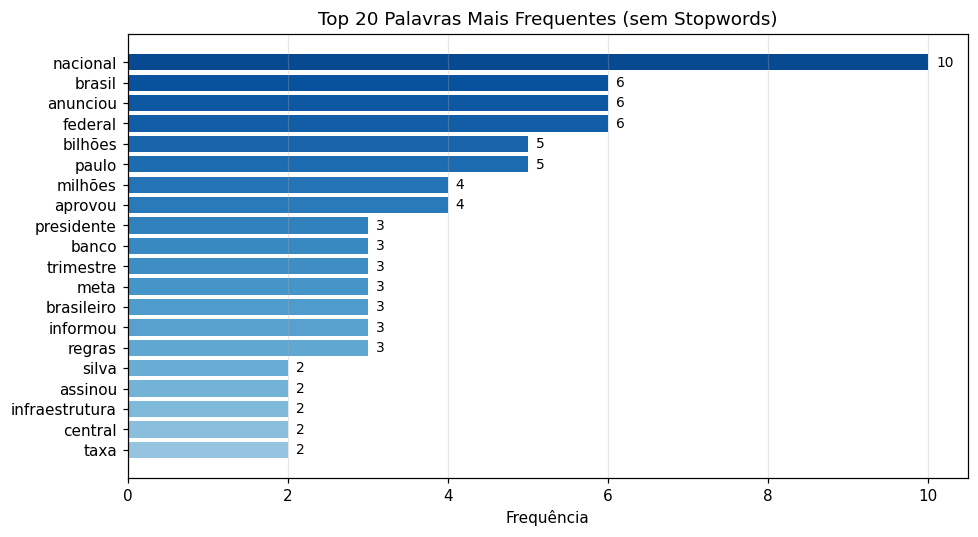


Top 20 palavras mais frequentes (sem stopwords):
-----------------------------------
  nacional             10
  brasil               6
  anunciou             6
  federal              6
  bilhões              5
  paulo                5
  milhões              4
  aprovou              4
  presidente           3
  banco                3
  trimestre            3
  meta                 3
  brasileiro           3
  informou             3
  regras               3
  silva                2
  assinou              2
  infraestrutura       2
  central              2
  taxa                 2


In [ ]:
all_tokens=[t for d in docs_proc for t in d['sem_sw']]
top_20=Counter(all_tokens).most_common(20)
palavras=[p[0] for p in top_20]; freqs=[p[1] for p in top_20]
fig, ax = plt.subplots(figsize=(9,5))
colors_c=plt.cm.Blues([0.4+0.5*i/len(palavras) for i in range(len(palavras))])[::-1]
bars=ax.barh(range(len(palavras)),freqs,color=colors_c)
ax.set_yticks(range(len(palavras))); ax.set_yticklabels(palavras,fontsize=10)
ax.invert_yaxis(); ax.set_title('Top 20 Palavras Mais Frequentes (sem Stopwords)')
for bar,freq in zip(bars,freqs): ax.text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2,str(freq),va='center')
ax.grid(axis='x',alpha=0.3); plt.tight_layout(); plt.show()

## 6. Salvando Resultados

In [ ]:
df_stats=pd.DataFrame([{'id':d['id'],'n_tokens':len(d['tokens']),'n_tokens_sem_sw':len(d['sem_sw'])} for d in docs_proc])
df_stats.to_csv('dataset_stats.csv',sep=';',index=False,encoding='utf-8')
print(f'dataset_stats.csv salvo! {len(df_stats)} documentos.')

dataset_stats.csv salvo! 32 documentos.
